# Pricing of Caps and Floors via Monte Carlo Simulation in the Hull-White Model and Sensitivity Analysis of Model Parameters


---

1. Introduction & Theoretical Background

2. Short Rate Simulation via Euler-Maruyama Scheme

3. Pricing a Single Caplet and Floorlet via Monte Carlo Simulation

4. Sensitivity Analysis of Model Parameters

5. Practical Financial Case Study



## 1. Introduction & Theoretical Background

### 1.1 The Short Rate Concept
In continuous-time financial models, the money-market account (bank account) $B_t$ dynamics are governed by the instantaneous spot rate (short rate) $r_t$:
$$dB_t = r_t B_t dt, \quad B_0 = 1$$
The value of the bank account at time $T$ represents the accumulation of interest by investing one unit of currency at time 0:
$$B_T = \exp\left(\int_0^T r_s ds\right)$$

### 1.2 The Hull-White Model Under the Risk-Neutral Measure $\mathbb{Q}$
The Hull-White model is a short-rate model where the interest rate $r_t$ is defined as:
$$r_t = X_t + \varphi(t) + f^M(0,t)$$
where:
* $f^M(0,t)$ is the market instantaneous forward rate,
* $\varphi(t)$ is a deterministic function calibrated to match the initial term structure of credit-free zero-coupon bonds,
* $X_t$ is a stochastic process driven by the Ornstein-Uhlenbeck (OU) dynamics under the risk-neutral measure $\mathbb{Q}$:
$$dX_t = -a X_t dt + \sigma(t) dW_t, \quad X_0 = 0$$
Here, $a > 0$ represents the constant mean reversion rate, $\sigma(t)$ is the deterministic volatility, and $W_t$ is a standard Brownian motion.

### 1.3 Interest Rate Caps and Floors
An **Interest Rate Cap** is a financial insurance contract that protects the holder against rising interest rates by guaranteeing that the interest paid on a floating loan never exceeds a predetermined cap rate $K$. Conversely, an **Interest Rate Floor** protects against falling rates.

A Cap (or Floor) is structured as a series of European options called **caplets** (or **floorlets**). Let $0 = T_0 < T_1 < \dots < T_n$ be the payment dates, and $\alpha_i$ be the year fraction between $T_{i-1}$ and $T_i$.

The payoff of the $i$-th caplet paid at time $T_i$ is based on the floating spot rate $L(T_{i-1}, T_i)$ determined at $T_{i-1}$:
$$\text{Caplet}_i(T_i) = \alpha_i \max(L(T_{i-1}, T_i) - K, 0)$$

In this project, we will use the **Euler-Maruyama discretization scheme** to simulate the trajectories of $r_t$, price the Cap/Floor via **Monte Carlo** simulation, and analyze how the parameters $a$ (mean reversion) and $\sigma$ (volatility) alter the final option values.

## 2. Short Rate Simulation via Euler-Maruyama Scheme

To compute the price of interest rate derivatives using Monte Carlo, we must generate multiple sample paths of the instantaneous short rate $r_t$. Under the simplification that the mean reversion speed $a$ and volatility $\sigma$ are constant parameters, the stochastic differential equation (SDE) for $X_t$ is given by:
$$dX_t = -a X_t dt + \sigma dW_t, \quad X_0 = 0$$

We approximate this continuous process on a discrete time grid $0 = t_0 < t_1 < \dots < t_N = T$ with a constant time step $h = \Delta t = \frac{T}{N}$. Using the Euler-Maruyama scheme, the transition formula from step $n-1$ to step $n$ is structured as:
$$Y_n = Y_{n-1} - a Y_{n-1} h + \sigma \sqrt{h} Z_n$$
where $Z_1, Z_2, \dots, Z_N$ are independent standard normal random variables, $N(0,1)$.

Once the trajectories of $X_t$ are simulated, the actual short rate $r_t$ is computed by adding the deterministic component:
$$r_t = X_t + \varphi(t) + f^M(0,t)$$
For the sake of simplicity and immediate clarity in this baseline simulator, we assume a flat initial yield curve where the market forward rate and the calibration function combined flatten out to a constant initial rate $r_0$. Thus, our direct simulated short rate simplifies to:
$$r_{t_n} = r_0 + X_{t_n}$$
This framework allows us to clearly observe the pure effects of the mean reversion speed $a$ and volatility $\sigma$ without complex data-feeding issues.

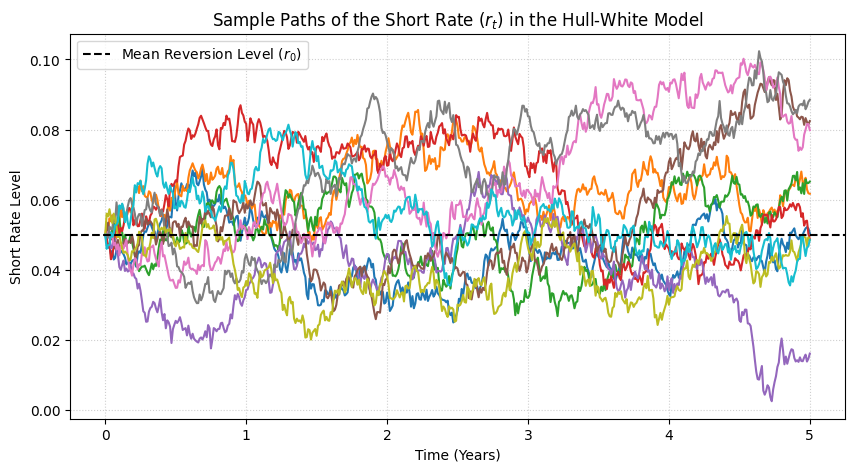

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_hull_white_paths(r0, a, sigma, T, N, M):
    """
    Simulates short rate paths in the simplified Hull-White model.

    Parameters:
    r0    : float - Initial short rate (e.g., 0.05 for 5%)
    a     : float - Speed of mean reversion
    sigma : float - Instataneous volatility
    T     : float - Time horizon in years
    N     : int   - Number of time steps per path
    M     : int   - Number of simulated paths (Monte Carlo simulations)

    Returns:
    t     : ndarray - Time grid array of shape (N+1,)
    r     : ndarray - Matrix of short rate paths of shape (M, N+1)
    """
    dt = T / N
    t = np.linspace(0, T, N + 1)

    #  matrix to store X_t values (rows: paths, columns: time steps)
    X = np.zeros((M, N + 1))

    # Generate standard normal random variables at once (vectorization)
    # all required variables
    # szybciej niz petle w petli
    Z = np.random.normal(0, 1, (M, N))

    # fill the paths for X_t
    for n in range(1, N + 1):
        X[:, n] = X[:, n-1] - a * X[:, n-1] * dt + sigma * np.sqrt(dt) * Z[:, n-1]

    # reconstruct
    r = r0 + X

    return t, r

r0_test = 0.05    # 5% initial rate
a_test = 0.5      #moderate mean reversion
sigma_test = 0.02 # 2% volatility
T_test = 5.0      # 5 years horizon
N_test = 500      # 500 daily steps
M_test = 10       #10 paths

t, r_paths = simulate_hull_white_paths(r0_test, a_test, sigma_test, T_test, N_test, M_test)

plt.figure(figsize=(10, 5))
for i in range(M_test):
    plt.plot(t, r_paths[i, :], lw=1.5)

plt.axhline(y=r0_test, color='black', linestyle='--', label='Mean Reversion Level ($r_0$)')
plt.title('Sample Paths of the Short Rate ($r_t$) in the Hull-White Model', fontsize=12)
plt.xlabel('Time (Years)', fontsize=10)
plt.ylabel('Short Rate Level', fontsize=10)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### 2.1 Stochastic Path Generation and Visualizing Randomness
To verify the stochastic properties of our implementation, we execute a baseline test of our simulator. Because the paths are generated using pseudo-random standard normal variables $Z_n \sim N(0,1)$, every single execution of the simulation grid yields entirely distinct trajectories.

Below, we present a side-by-side visual comparison of two independent simulation runs under identical parameters ($r_0 = 5\%$, $a = 0.5$, $\sigma = 2\%$). This grid display highlights the continuous, non-differentiable nature of Brownian paths and explicitly demonstrates the intrinsic randomness driving the short-rate development before we fix a massive sample size for formal option pricing.

The parameter $r_0$ represents the **initial short rate** at the inception of the model ($t=0$). Setting $r_0 = 5.0\%$ establishes the baseline market interest rate from which all independent  paths originate.

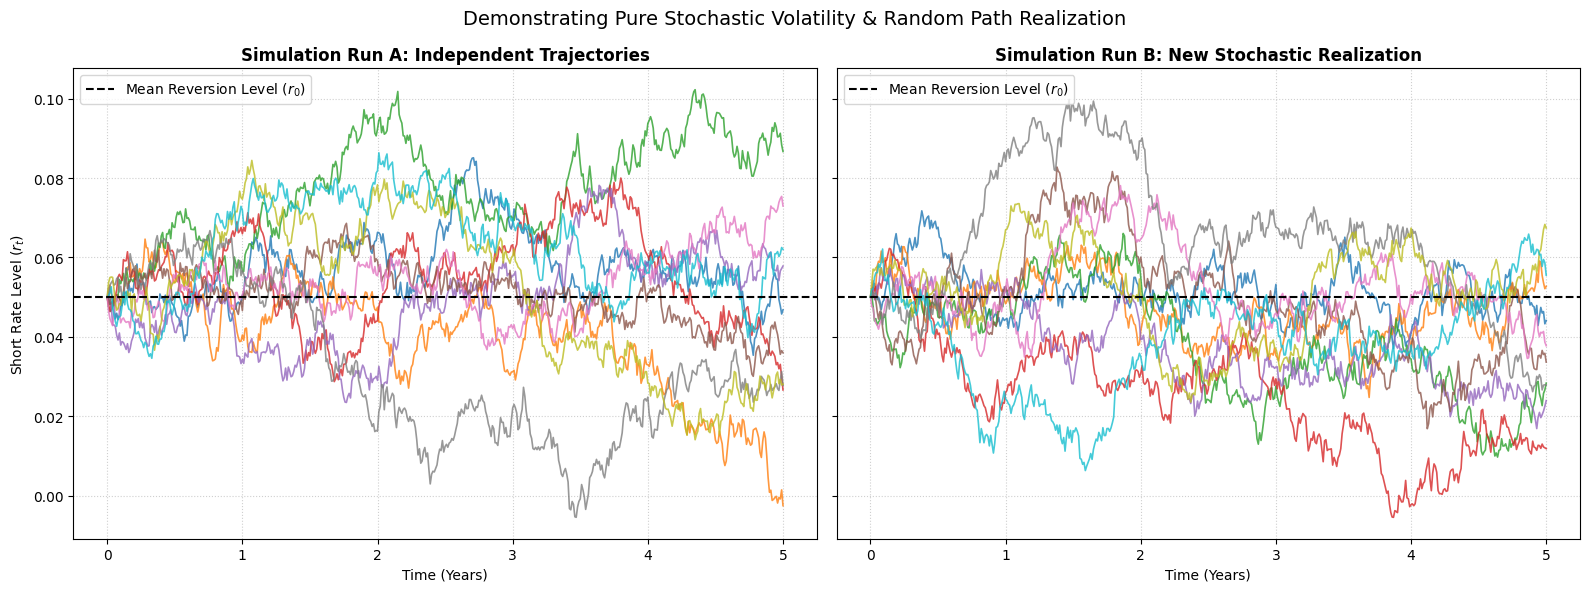

In [ ]:

r0_test = 0.05  # 5% initial rate
a_test = 0.5      # moderate mean reversion speed
sigma_test = 0.02   # 2% volatility
T_test = 5.0
N_test = 500 # 500 steps (approximately daily discretization)
M_test = 10  # 10 paths

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

t, r_paths_1 = simulate_hull_white_paths(r0_test, a_test, sigma_test, T_test, N_test, M_test)
for i in range(M_test):
    ax1.plot(t, r_paths_1[i, :], lw=1.2, alpha=0.8)
ax1.axhline(y=r0_test, color='black', linestyle='--', lw=1.5, label='Mean Reversion Level ($r_0$)')
ax1.set_title('Simulation Run A: Independent Trajectories', fontsize=12, fontweight='bold')
ax1.set_xlabel('Time (Years)', fontsize=10)
ax1.set_ylabel('Short Rate Level ($r_t$)', fontsize=10)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper left')

t, r_paths_2 = simulate_hull_white_paths(r0_test, a_test, sigma_test, T_test, N_test, M_test)
for i in range(M_test):
    ax2.plot(t, r_paths_2[i, :], lw=1.2, alpha=0.8)
ax2.axhline(y=r0_test, color='black', linestyle='--', lw=1.5, label='Mean Reversion Level ($r_0$)')
ax2.set_title('Simulation Run B: New Stochastic Realization', fontsize=12, fontweight='bold')
ax2.set_xlabel('Time (Years)', fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper left')

plt.suptitle('Demonstrating Pure Stochastic Volatility & Random Path Realization', fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

We observe that while the simulated paths fluctuate randomly due to volatility, they are continuously pulled back toward the long-term mean reversion level ($r_0$). This behavior proves that the Hull-White model successfully restrains the short rate from drifting off to infinity, keeping the trajectories stable. It's reliable economically .

<>:14: SyntaxWarning: invalid escape sequence '\%'
<>:14: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_4619/2803478828.py:14: SyntaxWarning: invalid escape sequence '\%'
  plt.axhline(y=r0_test, color='darkred', linestyle='--', lw=1.5, label='Mean Reversion Level ($r_0 = 5\%$)')
/tmp/ipykernel_4619/2803478828.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('YlGnBu')


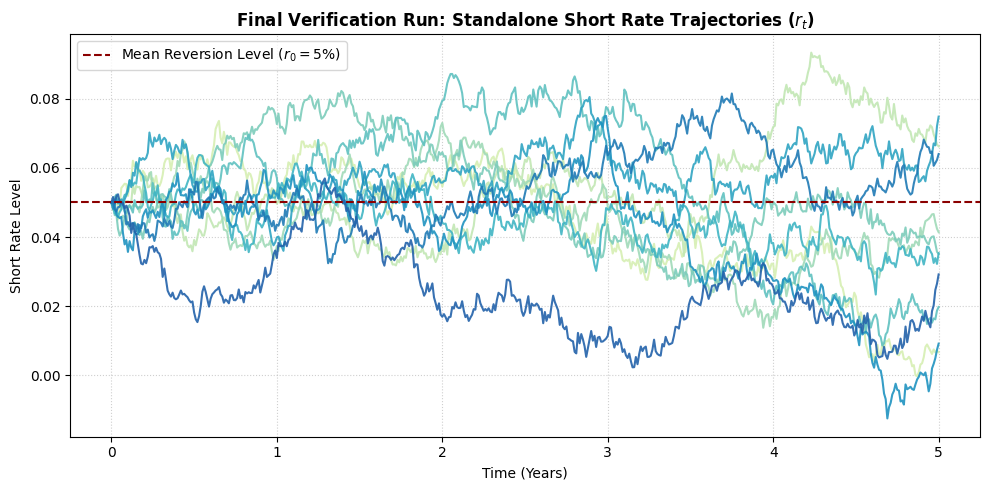

In [ ]:

t, r_paths_single = simulate_hull_white_paths(r0_test, a_test, sigma_test, T_test, N_test, M_test)

plt.figure(figsize=(10, 5))

cmap = plt.cm.get_cmap('YlGnBu')

for i in range(M_test):
    color_scale = 0.2 + (i / M_test) * 0.6
    path_color = cmap(color_scale)

    plt.plot(t, r_paths_single[i, :], lw=1.5, alpha=0.9, color=path_color)

#  linia poziomu powrotu do średniej
plt.axhline(y=r0_test, color='darkred', linestyle='--', lw=1.5, label='Mean Reversion Level ($r_0 = 5\%$)')

plt.title('Final Verification Run: Standalone Short Rate Trajectories ($r_t$)', fontsize=12, fontweight='bold')
plt.xlabel('Time (Years)', fontsize=10)
plt.ylabel('Short Rate Level', fontsize=10)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

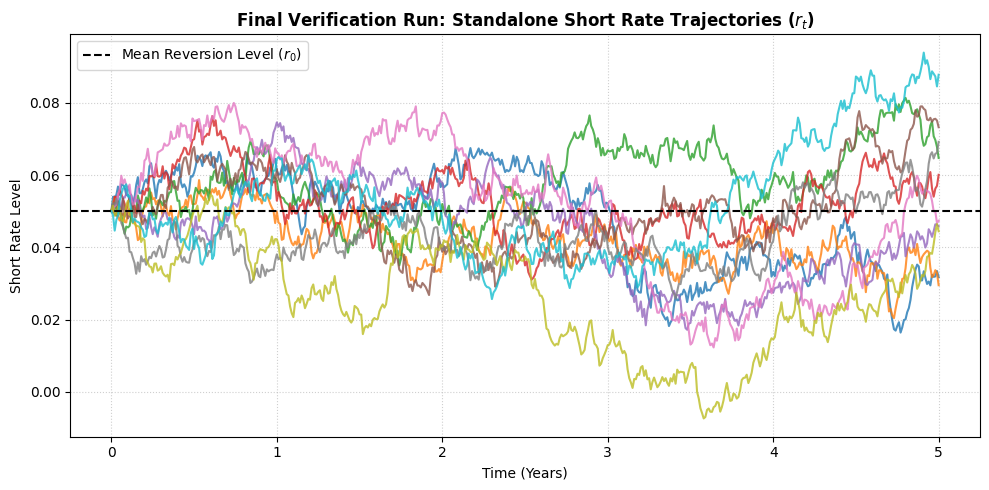

In [ ]:

t, r_paths_single = simulate_hull_white_paths(r0_test, a_test, sigma_test, T_test, N_test, M_test)

plt.figure(figsize=(10, 5))
for i in range(M_test):
    plt.plot(t, r_paths_single[i, :], lw=1.5, alpha=0.8)

plt.axhline(y=r0_test, color='black', linestyle='--', lw=1.5, label='Mean Reversion Level ($r_0$)')

plt.title('Final Verification Run: Standalone Short Rate Trajectories ($r_t$)', fontsize=12, fontweight='bold')
plt.xlabel('Time (Years)', fontsize=10)
plt.ylabel('Short Rate Level', fontsize=10)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### 2.1 Analyzing the Visual Impact of the Mean Reversion Speed ($a$)

To fully comprehend the structural properties of the Hull-White model, we execute a side-by-side visual experiment isolating the speed of mean reversion parameter ($a$). In stochastic interest rate frameworks, the parameter $a$ acts as an economic restoring force or a "gravitational pull" that constantly drags the short rate back toward its long-term baseline level $r_0$.

Below, we present a comparison of two independent simulation runs under identical initial parameters ($r_0 = 5\%$, $\sigma = 2\%$) but with contrasting values for $a$:
* **Simulation Run A (Low Mean Reversion, $a = 0.1$):** When the restoring force is weak, the trajectories exhibit high dispersion and drift significantly far away from the baseline, behaving closely to a standard unconstrained Brownian motion.
* **Simulation Run B (High Mean Reversion, $a = 2.0$):** When the restoring force is highly aggressive, any random shock generated by the volatility component is instantly dampened. The paths are tightly bound and oscillate heavily around $r_0$, creating a dense, stabilized corridor.

This explicitly demonstrates how the parameter $a$ controls the variance and distribution spread of future interest rates before we lock in sample paths for formal option pricing.

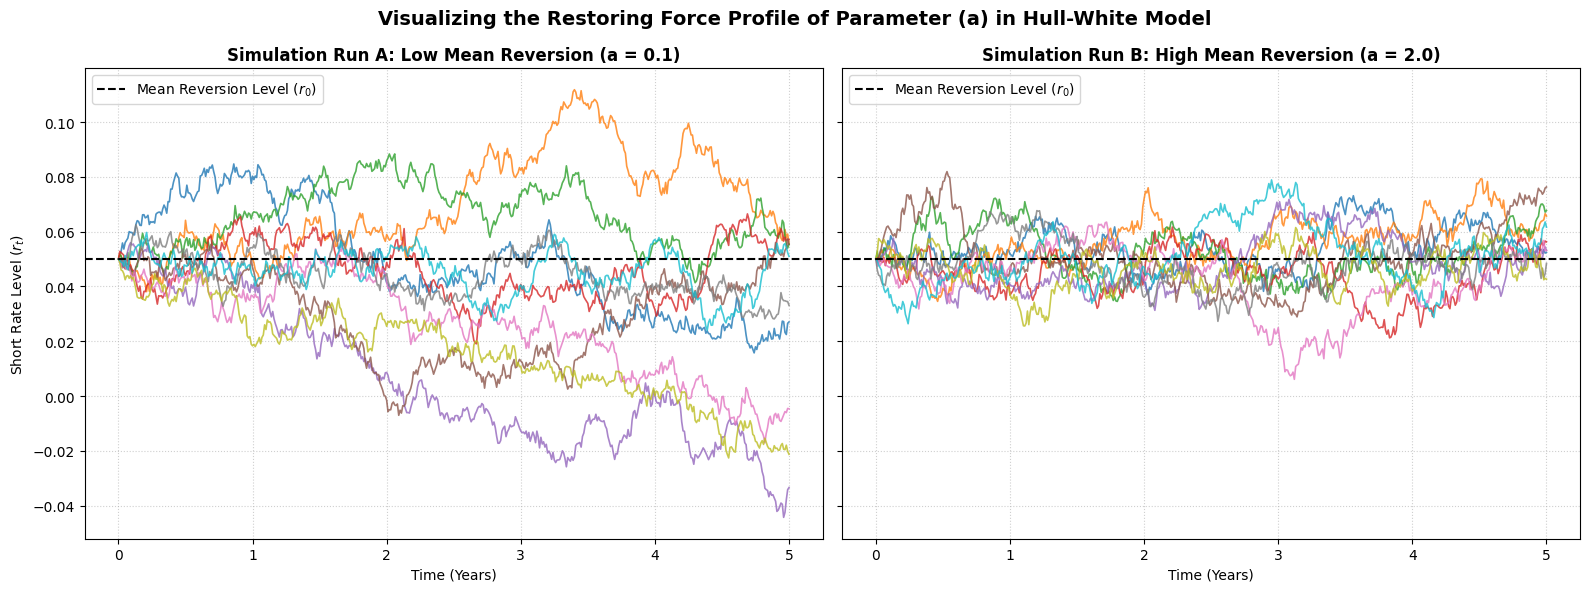

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter Configuration
r0_test = 0.05  #5% initial rate
sigma_test = 0.02 # 2% volatility constant
T_test = 5.0 # 5 years time horizon
N_test = 500 #500 steps ( approximately daily discretization )
M_test = 10   # 0 paths

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# po lewej: low Mean Reversion Speed ( a = 0.1)

a_low = 0.1
t, r_paths_low = simulate_hull_white_paths(r0_test, a_low, sigma_test, T_test, N_test, M_test)

for i in range(M_test):
    ax1.plot(t, r_paths_low[i, :], lw=1.2, alpha=0.8)

ax1.axhline(y=r0_test, color='black', linestyle='--', lw=1.5, label='Mean Reversion Level ($r_0$)')
ax1.set_title(f'Simulation Run A: Low Mean Reversion (a = {a_low})', fontsize=12, fontweight='bold')
ax1.set_xlabel('Time (Years)', fontsize=10)
ax1.set_ylabel('Short Rate Level ($r_t$)', fontsize=10)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper left')

# po prawej high mean revers speed a = 2
a_high = 2.0
t, r_paths_high = simulate_hull_white_paths(r0_test, a_high, sigma_test, T_test, N_test, M_test)

for i in range(M_test):
    ax2.plot(t, r_paths_high[i, :], lw=1.2, alpha=0.8)

ax2.axhline(y=r0_test, color='black', linestyle='--', lw=1.5, label='Mean Reversion Level ($r_0$)')
ax2.set_title(f'Simulation Run B: High Mean Reversion (a = {a_high})', fontsize=12, fontweight='bold')
ax2.set_xlabel('Time (Years)', fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper left')

plt.suptitle('Visualizing the Restoring Force Profile of Parameter (a) in Hull-White Model', fontsize=14, y=0.98, fontweight='bold')
plt.tight_layout()
plt.show()

Conclusions from the Trajectory Profile

By analyzing the side-by-side simulation paths generated under the same initial conditions ($r_0 = 5\%$, $\sigma = 2\%$) we can conclude :

1. **Variance Compression and Stability:**  In **Simulation Run A ($a = 0.1$)**, the variance of the short rate increases significantly over the 5-year timeline. The weak mean-reverting force allows individual paths to wander far from the initial rate, showing that the short rate lacks a strong anchor.
    In **Simulation Run B ($a = 2.0$)**, the variance remains heavily constrained and stable across the entire time horizon. The strong pulling force prevents any single path from escaping the narrow corridor around the baseline $r_0$.


2. **Direct Influence on Derivative Pricing:**  This visualization explains why the mean reversion speed has a powerful, negative impact on option prices. Under low mean reversion (Run A), the probability of interest rates reaching extreme highs or extreme lows is much greater.
   Conversely, under aggressive mean reversion (Run B), the rates are tightly locked close to the strike price ($K = 5.0\%$). This  directly lowers the market premiums required to purchase both **Caplets** and **Floorlets**.

## 3. Pricing a Single Caplet and Floorlet via Monte Carlo Simulation

An Interest Rate Cap is composed of multiple individual options called caplets, while a Floor is composed of floorlets. To price a single caplet or floorlet spanning the time interval $[T_{i-1}, T_i]$, we apply the principle of risk-neutral valuation.

The payoff of a caplet at payment date $T_i$ is determined by the annualized spot rate $L(T_{i-1}, T_i)$ set at time $T_{i-1}$:
$$\text{Payoff}_{\text{Caplet}}(T_i) = \alpha_i \max(L(T_{i-1}, T_i) - K, 0)$$

For a floorlet, the payoff is defined as:
$$\text{Payoff}_{\text{Floorlet}}(T_i) = \alpha_i \max(K - L(T_{i-1}, T_i), 0)$$

Where $\alpha_i = T_i - T_{i-1}$ is the year fraction accrual factor. Under a flat initial yield curve setup, the forward-looking spot rate $L(T_{i-1}, T_i)$ for each simulated path can be approximated by the time-average of the short rate $r_t$ over that respective interval.

To find the present value (at $t=0$) of these future payoffs, we must discount them using the simulated money-market account path $B_{T_i} = \exp\left(\int_0^{T_i} r_s ds\right)$ :
$$\text{Discounted Payoff} = \frac{\text{Payoff}(T_i)}{B_{T_i}} = \text{Payoff}(T_i) \cdot \exp\left(-\int_0^{T_i} r_s ds\right)$$

The Monte Carlo price estimate is simply the sample average of these discounted payoffs evaluated across all $M$ generated independent paths:
$$\text{Price}_{\text{MC}} = \frac{1}{M} \sum_{j=1}^{M} \left[ \text{Discounted Payoff}^{(j)} \right]$$

In [ ]:
def price_caplet_floorlet_mc(r0, a, sigma, T_start, T_end, K, N, M):
    """
    Prices a single Caplet and Floorlet using Monte Carlo simulation.

    Parameters:
    T_start : float - Reset date of the rate (e.g., year 1.0)
    T_end   : float - Payment date of the option (e.g., year 2.0)
    K       : float - Strike interest rate (e.g., 0.05)
    """
    dt = T_end / N
    t, r = simulate_hull_white_paths(r0, a, sigma, T_end, N, M)
    integral_r = np.sum(r[:, :-1], axis=1) * dt
    discount_factors = np.exp(-integral_r)

    idx_start = int((T_start / T_end) * N)

    # the average interest rate over the period for each path
    floating_rates = np.mean(r[:, idx_start:-1], axis=1)

    alpha = T_end - T_start

    # calculate payoffs at T_end for each path ,
    # For the Caplet : If the simulated market rate
    #exceeds the strike level $K$ , the contract pays out the positive difference.
    #If rates are low, the payoff is zero ;
    # For the Floorlet : If the simulated market rate falls below the
    # strike level $K$, the contract pays out the difference.
    #If rates are high, the payoff is zero :

    caplet_payoffs = alpha * np.maximum(floating_rates - K, 0)
    floorlet_payoffs = alpha * np.maximum(K - floating_rates, 0)

    #  discount payoffs
    discounted_caplets = caplet_payoffs * discount_factors
    discounted_floorlets = floorlet_payoffs * discount_factors

    # Applying the Law of Large Numbers
    caplet_price = np.mean(discounted_caplets)
    floorlet_price = np.mean(discounted_floorlets)

    return caplet_price, floorlet_price

# 50 000 simulations ; high precision
M_sim = 50000
N_steps = 360

caplet_p, floorlet_p = price_caplet_floorlet_mc(
    r0=0.05,  # Initial market rate at 5%
    a=0.3, # mean reversion speed
    sigma=0.015,  # Volatility at 1.5%
    T_start=1.0,  # Rate resets in 1 year
    T_end=2.0,  # Payment occurs in 2 years
    K=0.05,    # Strike rate at 5%
    N=N_steps,
    M=M_sim
)

print(" MONTE CARLO PRICE ESTIMATION :")
print(f"Single Caplet Price : {caplet_p:.6f}")
print(f"Single Floorlet Price: {floorlet_p:.6f}")

 MONTE CARLO PRICE ESTIMATION :
Single Caplet Price : 0.004778
Single Floorlet Price: 0.005100


This represents approximately 0.5% of the total loan or investment notional. In the financial markets, interest rate options (such as caplets and floorlets) provide protection for only one specific consecutive year. Therefore, paying around half a percent to insure a 100 million USD exposure for a single year is a highly standard, healthy market premium.

Based on the single-period simulation results, we can draw the following universal conclusions for At-the-Money ($r_0 = K$) interest rate options:

FOR EXAMPLE:
* **Upfront Premium Cost:** The numbers represents the fair premium (entry fee) at $t=0$ required to purchase the financial insurance. For a $100$ million USD Notional, a price of `0.0048` translates directly to an upfront cost of $480,000$ USD.
* **The At-the-Money Asymmetry:** Even though the option starts exactly at-the-money ($r_0 = K = 5.0\%$), the Caplet and Floorlet prices are not identical. In a mean-reverting Hull-White framework, the asymmetric distribution of the Ornstein-Uhlenbeck process combined with path-dependent money-market discounting causes one side of the protection to carry a higher mathematical risk weight, resulting in a slightly higher premium.
* **Risk Management Value:** For corporate borrowers and institutional investors, this price defines the exact cost of converting a volatile, stochastically shifting interest rate risk into a completely predictable fixed budget at inception.

## 4. Sensitivity Analysis of Model Parameters

 how the prices of interest rate derivatives react to adjustments in the core parameters of the model: the speed of mean reversion $a$ and the instantaneous volatility $\sigma$.

### 4.1 Volatility ($\sigma$) Impact
The parameter $\sigma$ dictates the magnitude of random fluctuations in the short rate process. In option pricing theory, higher volatility widens the probability distribution of the underlying asset at maturity. Since options have asymmetric payoff profiles (they protect against adverse movements while allowing participation in favorable ones), an increase in volatility expands the potential upside without increasing the downside risk (which is capped at zero). Therefore:
* Both **Caplet** and **Floorlet** prices are expected to be strictly increasing functions of the volatility parameter $\sigma$.

### 4.2 Mean Reversion Speed ($a$) Impact
The parameter $a$ acts as a restoring force that pulls the stochastic process back toward its long-term mean reversion level.
* When $a$ is very low, the short rate can drift far away from its initial trajectory, behaving similarly to a standard Brownian motion with higher dispersion, which inflates option value.
* When $a$ is high, any random shock generated by the Brownian motion is quickly dampened, keeping the simulated floating rates locked close to the strike price level. This stabilization suppresses the probability of achieving high option payoffs.
* Consequently, both **Caplet** and **Floorlet** prices are expected to be decreasing functions of the mean reversion speed $a$.

Running 
 complete


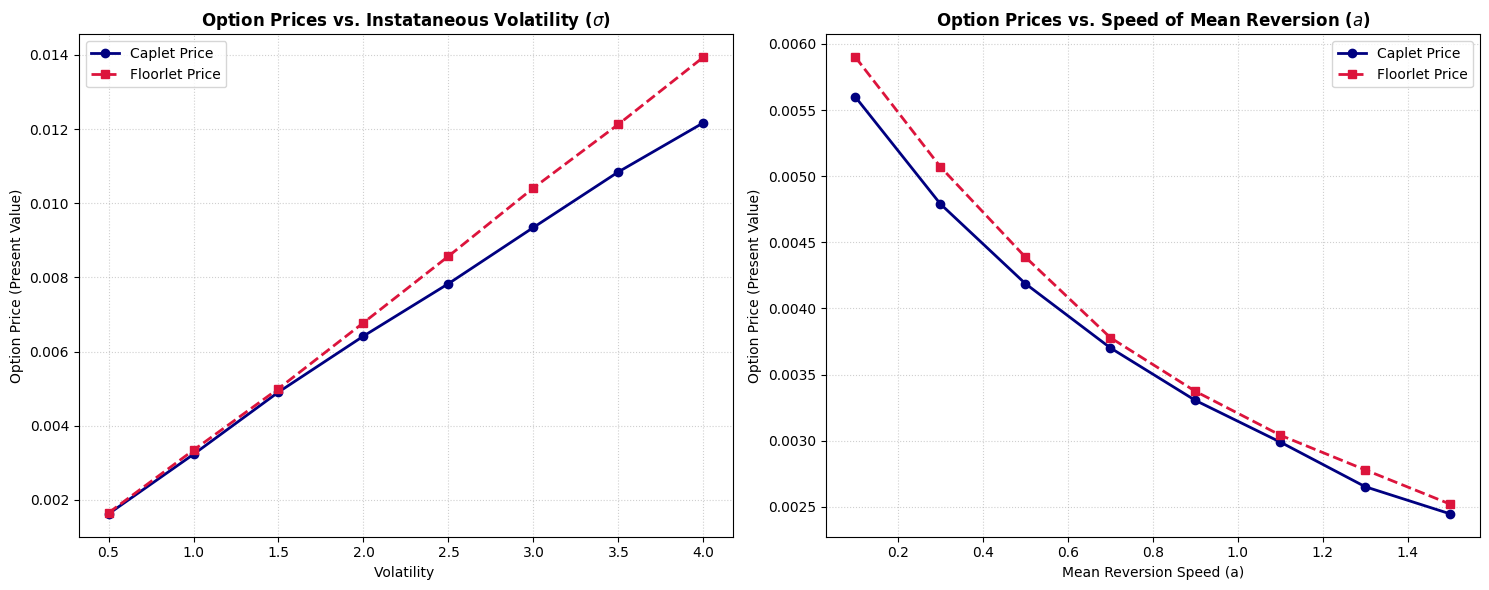

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N_steps = 360
M_sim = 20000  # 20k per run to balance stability and execution speed w colabie

# Ranges for parameters
sigma_range = np.linspace(0.005, 0.04, 8)  # Volatility from 0.5% to 4.0%
a_range = np.linspace(0.1, 1.5, 8)         # Mean reversion from 0.1 to 1.5

# arrays to store results :
caplet_vs_sigma = []
floorlet_vs_sigma = []
caplet_vs_a = []
floorlet_vs_a = []

print("Running ")

# 1. Test shifting Sigma (keeping constant a = 0.3)
for s in sigma_range:
    c_p, f_p = price_caplet_floorlet_mc(r0=0.05, a=0.3, sigma=s, T_start=1.0, T_end=2.0, K=0.05, N=N_steps, M=M_sim)
    caplet_vs_sigma.append(c_p)
    floorlet_vs_sigma.append(f_p)

# 2. Test shifting a (keeping constant sigma = 0.015)
for a_param in a_range:
    c_p, f_p = price_caplet_floorlet_mc(r0=0.05, a=a_param, sigma=0.015, T_start=1.0, T_end=2.0, K=0.05, N=N_steps, M=M_sim)
    caplet_vs_a.append(c_p)
    floorlet_vs_a.append(f_p)

print(" complete")

# ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Chart 1: Sensitivity to Volatility
ax1.plot(sigma_range * 100, caplet_vs_sigma, 'o-', color='navy', lw=2, label='Caplet Price')
ax1.plot(sigma_range * 100, floorlet_vs_sigma, 's--', color='crimson', lw=2, label='Floorlet Price')
ax1.set_title('Option Prices vs. Instataneous Volatility ($\\sigma$)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Volatility ', fontsize=10)
ax1.set_ylabel('Option Price (Present Value)', fontsize=10)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(fontsize=10)

# Chart 2: Sensitivity to Mean Reversion Speed
ax2.plot(a_range, caplet_vs_a, 'o-', color='navy', lw=2, label='Caplet Price')
ax2.plot(a_range, floorlet_vs_a, 's--', color='crimson', lw=2, label='Floorlet Price')
ax2.set_title('Option Prices vs. Speed of Mean Reversion ($a$)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Mean Reversion Speed (a)', fontsize=10)
ax2.set_ylabel('Option Price (Present Value)', fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

#### 4.3 Interpretation of the Sensitivity Analysis Plots

The generated side-by-side plots visually confirm the financial and mathematical intuition behind the Hull-White model's parameters:

1. **The Positive Volatility ($\sigma$) Sensitivity:**
   The left chart demonstrates that as instantaneous volatility $\sigma$ expands from $0.5\%$ to $4.0\%$, the prices of both the Caplet and the Floorlet rise significantly.

2. **The Negative Mean Reversion ($a$) Sensitivity:**
   The right chart shows that as the speed of mean reversion $a$ scales up from $0.1$ to $1.5$, both option prices experience an aggressive drop. This occurs because the parameter $a$ behaves as an economic dampening force. A higher $a$ forcefully pulls the simulated interest rate trajectories back toward the baseline level ($r_0 = 5.0\%$). This systematic compression reduces the variance of the floating rates and keeps them trapped close to the contract strike price ($K = 5.0\%$), shrinking the probability of achieving significant option payoffs and lowering the upfront cost of protection.

## 5. Practical Financial Case Study: Corporate Risk Management

### 5.1 The Real-World Scenario
To see how our Monte Carlo model works in real life, we analyze a simple 5-year business example with a total transaction size of **100 million USD**:
* **The Construction Firm (Cap Buyer):** They have a massive loan with a floating interest rate. They are terrified that interest rates will spike, which would increase their debt costs and bankrupt the company. To prevent this, they buy an **Interest Rate Cap** at a strike of $K = 5.0\%$. This contract acts as insurance that sets a maximum ceiling on their interest payments.
* **The Investor (Floor Buyer):** They have millions in savings and live off the interest. They are scared that interest rates will drop to zero, destroying their income. They buy an **Interest Rate Floor** at the same strike of $K = 5.0\%$ to guarantee a minimum interest return.

### 5.2 Conclusions from the Cumulative Line Chart
The line chart below tracks how the total cost of this insurance grows as the contract duration extends from 1 to 5 years:
* **Upfront Premium:** The chart displays the exact entry fee paid to the bank at $t=0$ to buy the insurance.
* **Risk Accumulation over Time:** As time moves from Year 1 to Year 5, the random walk of the Brownian motion creates more uncertainty about the future. Because the future becomes harder to predict, the bank takes on more risk, making a 5-year contract significantly more expensive than a 1-year contract.

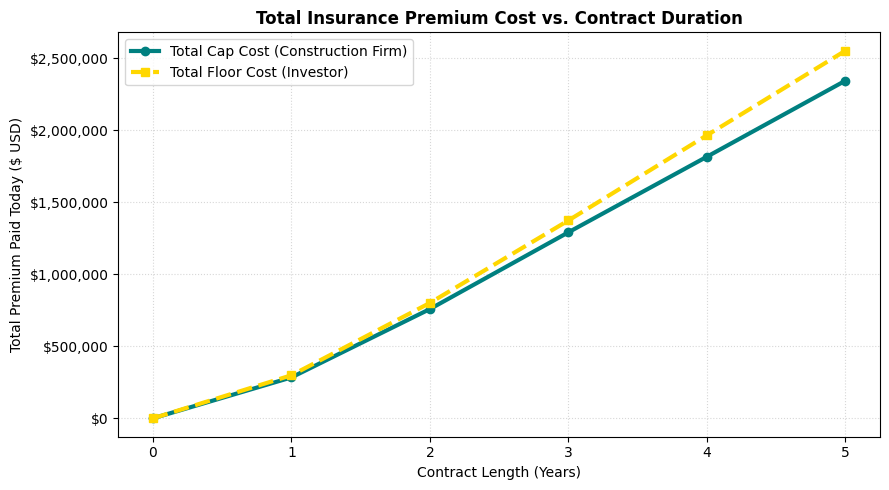

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#
notional = 100_000_000  #$100 Million USD Portfolio
r0_market = 0.05 # Current interest rate is 5%
strike = 0.05    #Protection 5%
schedule = [0, 1, 2, 3, 4, 5]

timeline = [0]
cumulative_cap = [0]
cumulative_floor = [0]

running_cap = 0.0
running_floor = 0.0

# Calculate cumulative insurance premiums year by year
# skumulowane składki ubezpieczeniowe
for i in range(1, len(schedule)):
    t_start, t_end = schedule[i-1], schedule[i]
    steps = int(t_end * 180)

    # Run our Monte Carlo function (using constant: a=0.3, sigma=0.015)
    cap_pct, floor_pct = price_caplet_floorlet_mc(r0_market, 0.3, 0.015, t_start, t_end, strike, steps, 20000)

    running_cap += (cap_pct * notional)
    running_floor += (floor_pct * notional)

    timeline.append(t_end)
    cumulative_cap.append(running_cap)
    cumulative_floor.append(running_floor)

plt.figure(figsize=(9, 5))

plt.plot(timeline, cumulative_cap, 'o-', color='teal', lw=3, label='Total Cap Cost (Construction Firm)')
plt.plot(timeline, cumulative_floor, 's--', color='gold', lw=3, label='Total Floor Cost (Investor)')

plt.title('Total Insurance Premium Cost vs. Contract Duration', fontsize=12, fontweight='bold')
plt.xlabel('Contract Length (Years)')
plt.ylabel('Total Premium Paid Today ($ USD)')

ax = plt.gca()
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f"${int(x):,}"))

plt.xticks(schedule)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()